PCA with Logistic Regression and SVM PROJECT — MNIST Digit Classification

In [ ]:
# ============================================================
# SECTION 0 — IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import tracemalloc
 
print("✓ All imports successful")

✓ All imports successful


In [3]:
# ============================================================
# SECTION 1 — LOAD & PREPROCESS MNIST
# ============================================================
print("\n[1/7] Loading MNIST (70,000 images × 784 pixels)...")
 
def load_mnist():
    try:
        print("  Keras.datasets.mnist...")
        import tensorflow as tf
        (X_tr, y_tr), (X_te, y_te) = tf.keras.datasets.mnist.load_data()
        X = np.vstack([X_tr, X_te]).reshape(-1, 784).astype(np.float32)
        y = np.concatenate([y_tr, y_te]).astype(int)
        print("  ✓ Loaded via Keras")
        return X, y
    except Exception as e:
        print(f"  ✗ Keras failed: {e}")
 
X, y = load_mnist()
 
print(f"  Dataset shape : {X.shape}")
print(f"  Labels        : {np.unique(y)}")
print(f"  Pixel range   : [{X.min():.0f}, {X.max():.0f}]")
 
# Use 10,000 samples for speed (use full set for max accuracy)
X_small, _, y_small, _ = train_test_split(X, y, train_size=10000,
                                           stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42)
 
print(f"\n  Train set: {X_train.shape[0]} samples")
print(f"  Test  set: {X_test.shape[0]} samples")
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("  ✓ Data standardized (mean≈0, std≈1 per pixel)")


[1/7] Loading MNIST (70,000 images × 784 pixels)...
  Keras.datasets.mnist...
  ✓ Loaded via Keras
  Dataset shape : (70000, 784)
  Labels        : [0 1 2 3 4 5 6 7 8 9]
  Pixel range   : [0, 255]

  Train set: 8000 samples
  Test  set: 2000 samples
  ✓ Data standardized (mean≈0, std≈1 per pixel)


In [5]:
# ============================================================
# SECTION 2 — BASELINE: LOGISTIC REGRESSION (WITHOUT PCA)
# ============================================================
print("\n[2/7] Training Logistic Regression WITHOUT PCA...")
 
model_base = LogisticRegression(max_iter=1000, C=1.0, random_state=42,
                                 solver='saga', n_jobs=-1)
tracemalloc.start()
t0 = time.perf_counter()
model_base.fit(X_train_scaled, y_train)
t_train_base = time.perf_counter() - t0
mem_base, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_base = model_base.predict(X_test_scaled)
acc_base    = accuracy_score(y_test, y_pred_base)
cm_base     = confusion_matrix(y_test, y_pred_base)
 
print(f"  Features used   : {X_train_scaled.shape[1]:>6}  (all pixels)")
print(f"  Training time   : {t_train_base:>6.2f}s")
print(f"  Memory (train)  : {mem_base/1e6:>6.2f} MB")
print(f"  Test accuracy   : {acc_base*100:>6.2f}%")
 


[2/7] Training Logistic Regression WITHOUT PCA...
  Features used   :    784  (all pixels)
  Training time   : 395.65s
  Memory (train)  :   0.04 MB
  Test accuracy   :  89.10%


In [4]:
# ============================================================
# [NEW] SECTION 3 — BASELINE: SVM (WITHOUT PCA)
# ============================================================
print("\n[3/7] Training SVM (RBF kernel) WITHOUT PCA...")
 
svm_base = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
 
tracemalloc.start()
t0 = time.perf_counter()
svm_base.fit(X_train_scaled, y_train)
t_svm_base = time.perf_counter() - t0
mem_svm_base, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_svm_base = svm_base.predict(X_test_scaled)
acc_svm_base    = accuracy_score(y_test, y_pred_svm_base)
cm_svm_base     = confusion_matrix(y_test, y_pred_svm_base)
 
print(f"  Features used   : {X_train_scaled.shape[1]:>6}  (all pixels)")
print(f"  Training time   : {t_svm_base:>6.2f}s")
print(f"  Memory (train)  : {mem_svm_base/1e6:>6.2f} MB")
print(f"  Test accuracy   : {acc_svm_base*100:>6.2f}%")


[3/7] Training SVM (RBF kernel) WITHOUT PCA...
  Features used   :    784  (all pixels)
  Training time   :  23.65s
  Memory (train)  :  23.40 MB
  Test accuracy   :  94.30%


In [6]:
# ============================================================
# SECTION 4 — FIND OPTIMAL PCA COMPONENTS
# ============================================================
print("\n[4/7] Fitting PCA and computing explained variance...")
 
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
 
for pct in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= pct) + 1
    print(f"  {pct*100:.0f}% variance explained by {n} components "
          f"({n/784*100:.1f}% of original features)")
 
N_COMPONENTS = int(np.argmax(cumvar >= 0.95)) + 1
print(f"\n  → Chosen: {N_COMPONENTS} components (95% variance threshold)")


[4/7] Fitting PCA and computing explained variance...
  80% variance explained by 122 components (15.6% of original features)
  90% variance explained by 199 components (25.4% of original features)
  95% variance explained by 283 components (36.1% of original features)
  99% variance explained by 488 components (62.2% of original features)

  → Chosen: 283 components (95% variance threshold)


In [7]:
# ============================================================
# SECTION 5 — APPLY PCA AND RETRAIN BOTH MODELS
# ============================================================
print(f"\n[5/7] Applying PCA ({N_COMPONENTS} components) and retraining...")
 
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
 
print(f"  Reduced: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features "
      f"({(1 - N_COMPONENTS/784)*100:.1f}% reduction)\n")
 
# — Logistic Regression + PCA —
model_pca = LogisticRegression(max_iter=1000, C=1.0, random_state=42,
                                solver='saga', n_jobs=-1)
tracemalloc.start()
t0 = time.perf_counter()
model_pca.fit(X_train_pca, y_train)
t_train_pca = time.perf_counter() - t0
mem_pca, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_pca = model_pca.predict(X_test_pca)
acc_pca    = accuracy_score(y_test, y_pred_pca)
cm_pca     = confusion_matrix(y_test, y_pred_pca)
 
print(f"  LR  + PCA | Acc: {acc_pca*100:.2f}% | "
      f"Time: {t_train_pca:.2f}s | Speedup: {t_train_base/t_train_pca:.1f}×")
 
# — SVM + PCA —
svm_pca = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
 
tracemalloc.start()
t0 = time.perf_counter()
svm_pca.fit(X_train_pca, y_train)
t_svm_pca = time.perf_counter() - t0
mem_svm_pca, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_svm_pca = svm_pca.predict(X_test_pca)
acc_svm_pca    = accuracy_score(y_test, y_pred_svm_pca)
cm_svm_pca     = confusion_matrix(y_test, y_pred_svm_pca)
 
print(f"  SVM + PCA | Acc: {acc_svm_pca*100:.2f}% | "
      f"Time: {t_svm_pca:.2f}s | Speedup: {t_svm_base/t_svm_pca:.1f}×")
 


[5/7] Applying PCA (283 components) and retraining...
  Reduced: 784 → 283 features (63.9% reduction)

  LR  + PCA | Acc: 89.40% | Time: 143.20s | Speedup: 2.8×
  SVM + PCA | Acc: 94.80% | Time: 12.46s | Speedup: 1.9×


In [ ]:
# ============================================================
# SECTION 6 — COMPARISON TABLE (LR + SVM)
# ============================================================
print("\n[6/7] FINAL COMPARISON TABLE")
print("=" * 70)
print(f"{'Metric':<26} {'LR Base':>10} {'LR+PCA':>10} "
      f"{'SVM Base':>10} {'SVM+PCA':>10}")
print("-" * 70)
print(f"{'Features':<26} {784:>10} {N_COMPONENTS:>10} {784:>10} {N_COMPONENTS:>10}")
print(f"{'Feature reduction':<26} {'–':>10} "
      f"{f'{(1-N_COMPONENTS/784)*100:.0f}%':>10} {'–':>10} "
      f"{f'{(1-N_COMPONENTS/784)*100:.0f}%':>10}")
print(f"{'Training time (s)':<26} {t_train_base:>10.2f} {t_train_pca:>10.2f} "
      f"{t_svm_base:>10.2f} {t_svm_pca:>10.2f}")
print(f"{'Speedup':<26} {'1.0×':>10} "
      f"{f'{t_train_base/t_train_pca:.1f}×':>10} {'1.0×':>10} "
      f"{f'{t_svm_base/t_svm_pca:.1f}×':>10}")
print(f"{'Memory (MB)':<26} {mem_base/1e6:>10.2f} {mem_pca/1e6:>10.2f} "
      f"{mem_svm_base/1e6:>10.2f} {mem_svm_pca/1e6:>10.2f}")
print(f"{'Test Accuracy':<26} {acc_base*100:>9.2f}% {acc_pca*100:>9.2f}% "
      f"{acc_svm_base*100:>9.2f}% {acc_svm_pca*100:>9.2f}%")
print(f"{'Accuracy delta':<26} {'–':>10} "
      f"{f'{(acc_pca-acc_base)*100:+.2f}%':>10} {'–':>10} "
      f"{f'{(acc_svm_pca-acc_svm_base)*100:+.2f}%':>10}")
print("=" * 70)
 


[6/7] FINAL COMPARISON TABLE
Metric                        LR Base     LR+PCA   SVM Base    SVM+PCA
----------------------------------------------------------------------
Features                          784        283        784        283
Feature reduction                   –        64%          –        64%
Training time (s)              395.65     143.20      23.65      12.46
Speedup                          1.0×       2.8×       1.0×       1.9×
Memory (MB)                      0.04       0.02      23.40       7.89
Test Accuracy                  89.10%     89.40%     94.30%     94.80%
Accuracy delta                      –     +0.30%          –     +0.50%



[7/7] Generating visualizations...


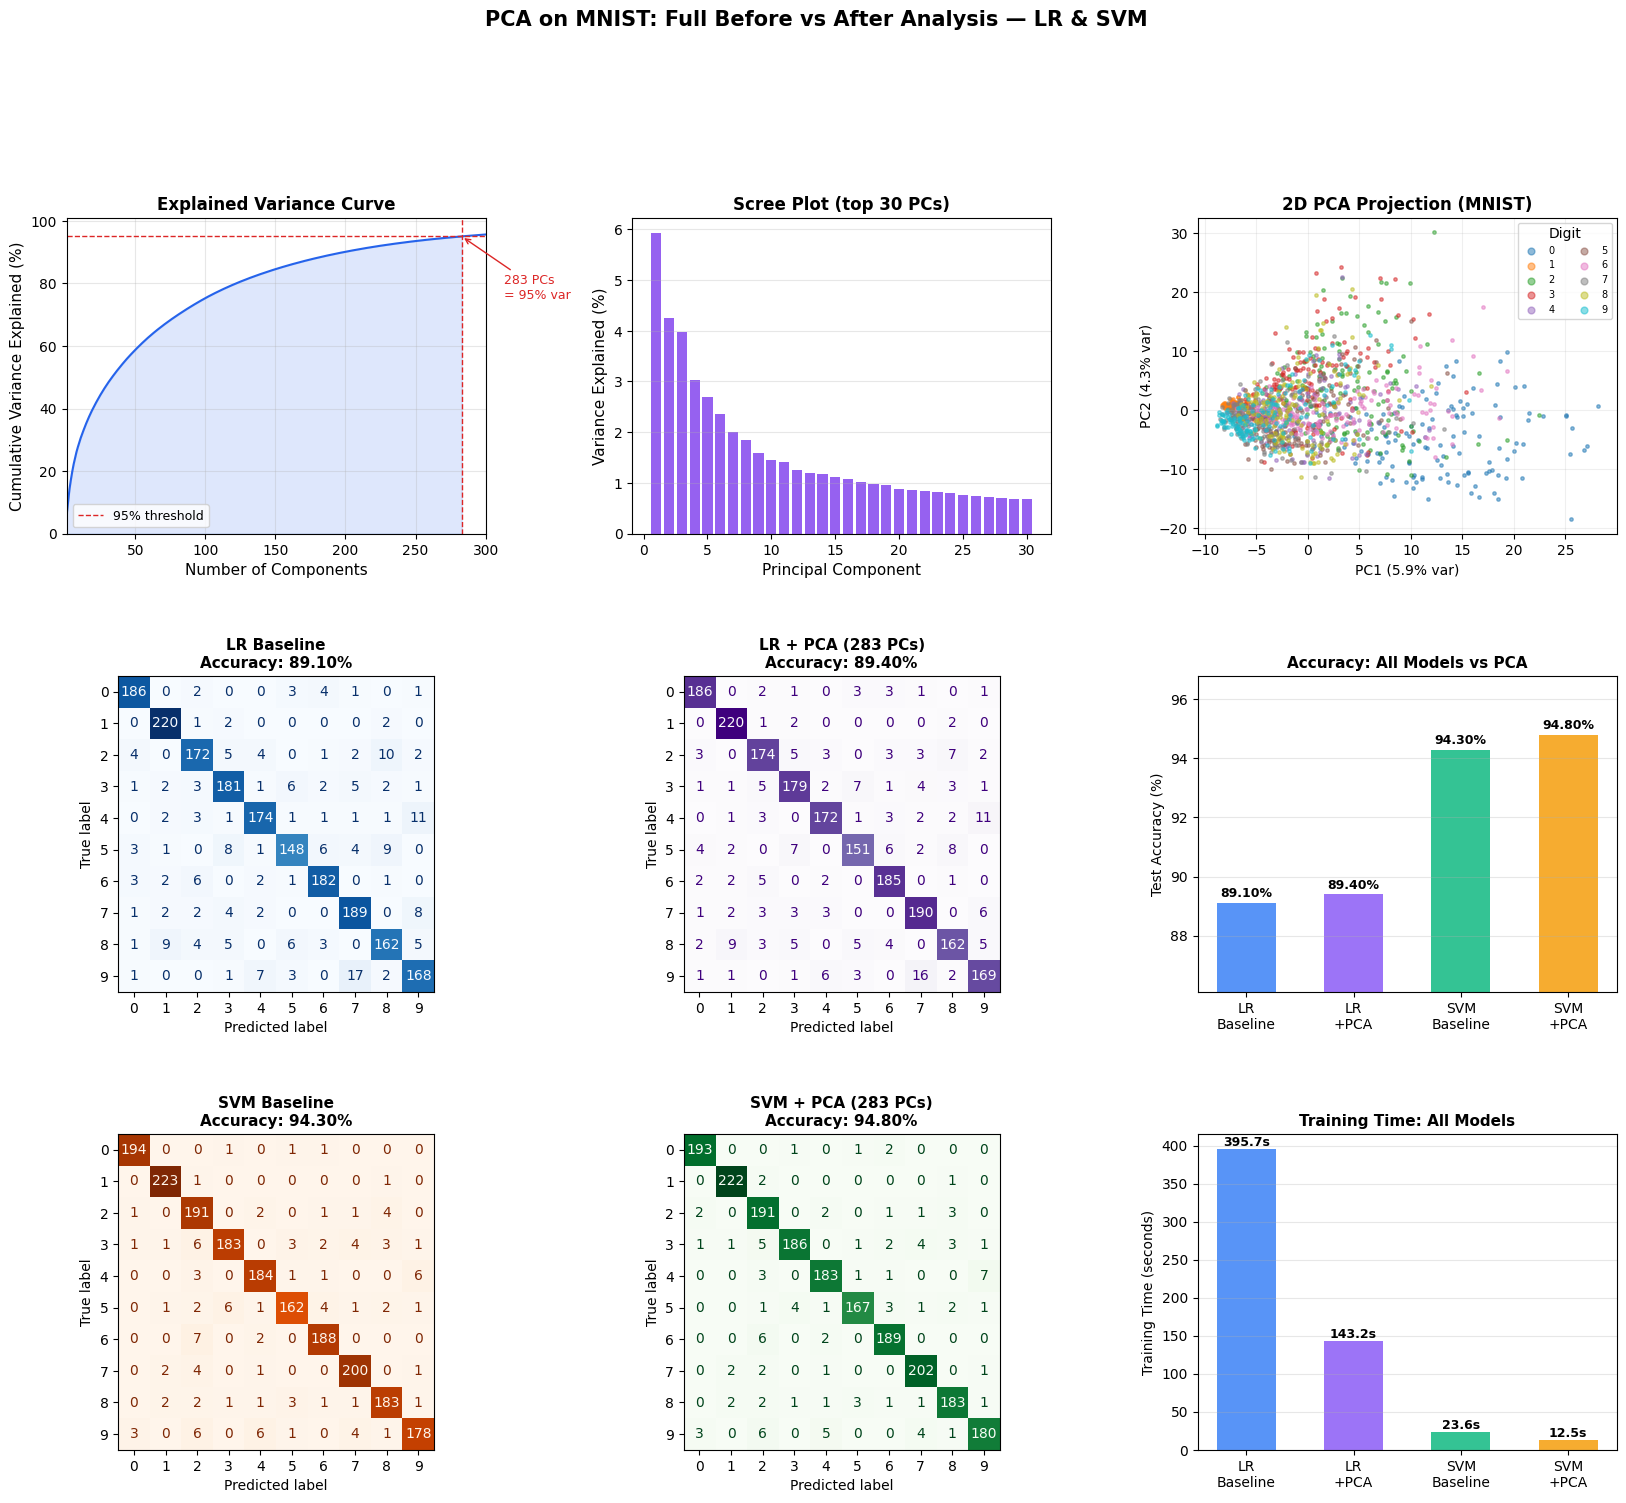

  ✓ Main figure saved.


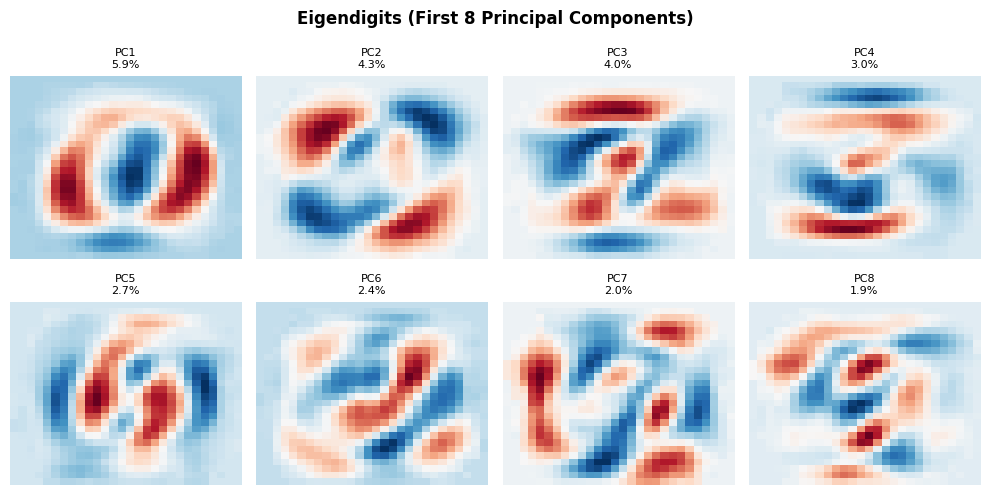

  ✓ Eigendigits figure saved.


In [9]:
# ============================================================
# [UPDATED] SECTION 7 — VISUALIZATIONS (adds SVM confusion matrices)
# ============================================================
print("\n[7/7] Generating visualizations...")
 
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# — Plot 1: Explained Variance Curve —
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(cumvar)+1), cumvar*100, color='#2563EB', linewidth=1.5)
ax1.axhline(95, color='#DC2626', linestyle='--', linewidth=1, label='95% threshold')
ax1.axvline(N_COMPONENTS, color='#DC2626', linestyle='--', linewidth=1)
ax1.fill_between(range(1, N_COMPONENTS+1), cumvar[:N_COMPONENTS]*100,
                  alpha=0.15, color='#2563EB')
ax1.set_xlabel('Number of Components', fontsize=11)
ax1.set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
ax1.set_title('Explained Variance Curve', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim([1, 300]); ax1.set_ylim([0, 101])
ax1.annotate(f'{N_COMPONENTS} PCs\n= 95% var',
             xy=(N_COMPONENTS, 95), xytext=(N_COMPONENTS+30, 75),
             arrowprops=dict(arrowstyle='->', color='#DC2626'),
             fontsize=9, color='#DC2626')
ax1.grid(True, alpha=0.3)
 
# — Plot 2: Scree Plot (top 30) —
ax2 = fig.add_subplot(gs[0, 1])
n_show = 30
ax2.bar(range(1, n_show+1),
        pca_full.explained_variance_ratio_[:n_show]*100,
        color='#7C3AED', alpha=0.8)
ax2.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_title(f'Scree Plot (top {n_show} PCs)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
 
# — Plot 3: 2D PCA Projection —
ax3 = fig.add_subplot(gs[0, 2])
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_scaled[:1500])
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for digit in range(10):
    mask = y_train[:1500] == digit
    ax3.scatter(X_2d[mask,0], X_2d[mask,1], s=6, alpha=0.5,
                color=colors[digit], label=str(digit))
ax3.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=10)
ax3.set_title('2D PCA Projection (MNIST)', fontsize=12, fontweight='bold')
ax3.legend(title='Digit', fontsize=7, ncol=2, loc='upper right', markerscale=2)
ax3.grid(True, alpha=0.2)
 
# — Plot 4: Confusion Matrix — LR Baseline —
ax4 = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(cm_base, display_labels=range(10)).plot(
    ax=ax4, cmap='Blues', colorbar=False, values_format='d')
ax4.set_title(f'LR Baseline\nAccuracy: {acc_base*100:.2f}%',
              fontsize=11, fontweight='bold')
 
# — Plot 5: Confusion Matrix — LR + PCA —
ax5 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(cm_pca, display_labels=range(10)).plot(
    ax=ax5, cmap='Purples', colorbar=False, values_format='d')
ax5.set_title(f'LR + PCA ({N_COMPONENTS} PCs)\nAccuracy: {acc_pca*100:.2f}%',
              fontsize=11, fontweight='bold')
 
# [NEW] — Plot 6: Accuracy bar chart — all 4 models —
ax6 = fig.add_subplot(gs[1, 2])
model_labels = ['LR\nBaseline', f'LR\n+PCA', 'SVM\nBaseline', 'SVM\n+PCA']
model_accs   = [acc_base, acc_pca, acc_svm_base, acc_svm_pca]
bar_colors   = ['#3B82F6', '#8B5CF6', '#10B981', '#F59E0B']
bars = ax6.bar(model_labels, [a*100 for a in model_accs],
               color=bar_colors, alpha=0.85, width=0.55)
for bar, a in zip(bars, model_accs):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{a*100:.2f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax6.set_ylabel('Test Accuracy (%)', fontsize=10)
ax6.set_title('Accuracy: All Models vs PCA', fontsize=11, fontweight='bold')
ax6.set_ylim([min(model_accs)*100 - 3, max(model_accs)*100 + 2])
ax6.grid(True, alpha=0.3, axis='y')
 
# [NEW] — Plot 7: Confusion Matrix — SVM Baseline —
ax7 = fig.add_subplot(gs[2, 0])
ConfusionMatrixDisplay(cm_svm_base, display_labels=range(10)).plot(
    ax=ax7, cmap='Oranges', colorbar=False, values_format='d')
ax7.set_title(f'SVM Baseline\nAccuracy: {acc_svm_base*100:.2f}%',
              fontsize=11, fontweight='bold')
 
# [NEW] — Plot 8: Confusion Matrix — SVM + PCA —
ax8 = fig.add_subplot(gs[2, 1])
ConfusionMatrixDisplay(cm_svm_pca, display_labels=range(10)).plot(
    ax=ax8, cmap='Greens', colorbar=False, values_format='d')
ax8.set_title(f'SVM + PCA ({N_COMPONENTS} PCs)\nAccuracy: {acc_svm_pca*100:.2f}%',
              fontsize=11, fontweight='bold')
 
# [NEW] — Plot 9: Training time comparison —
ax9 = fig.add_subplot(gs[2, 2])
model_times = [t_train_base, t_train_pca, t_svm_base, t_svm_pca]
bars2 = ax9.bar(model_labels, model_times, color=bar_colors, alpha=0.85, width=0.55)
for bar, t in zip(bars2, model_times):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{t:.1f}s', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax9.set_ylabel('Training Time (seconds)', fontsize=10)
ax9.set_title('Training Time: All Models', fontsize=11, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')
 
fig.suptitle('PCA on MNIST: Full Before vs After Analysis — LR & SVM',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('pca_mnist_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("  ✓ Main figure saved.")
 
# — Eigendigits —
fig_ef, axes_ef = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes_ef.flat):
    ax.imshow(pca_full.components_[i].reshape(28, 28), cmap='RdBu_r', aspect='auto')
    ax.set_title(f'PC{i+1}\n{pca_full.explained_variance_ratio_[i]*100:.1f}%', fontsize=8)
    ax.axis('off')
fig_ef.suptitle('Eigendigits (First 8 Principal Components)',
                fontsize=12, fontweight='bold')
fig_ef.tight_layout()
plt.savefig('eigendigits.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("  ✓ Eigendigits figure saved.")

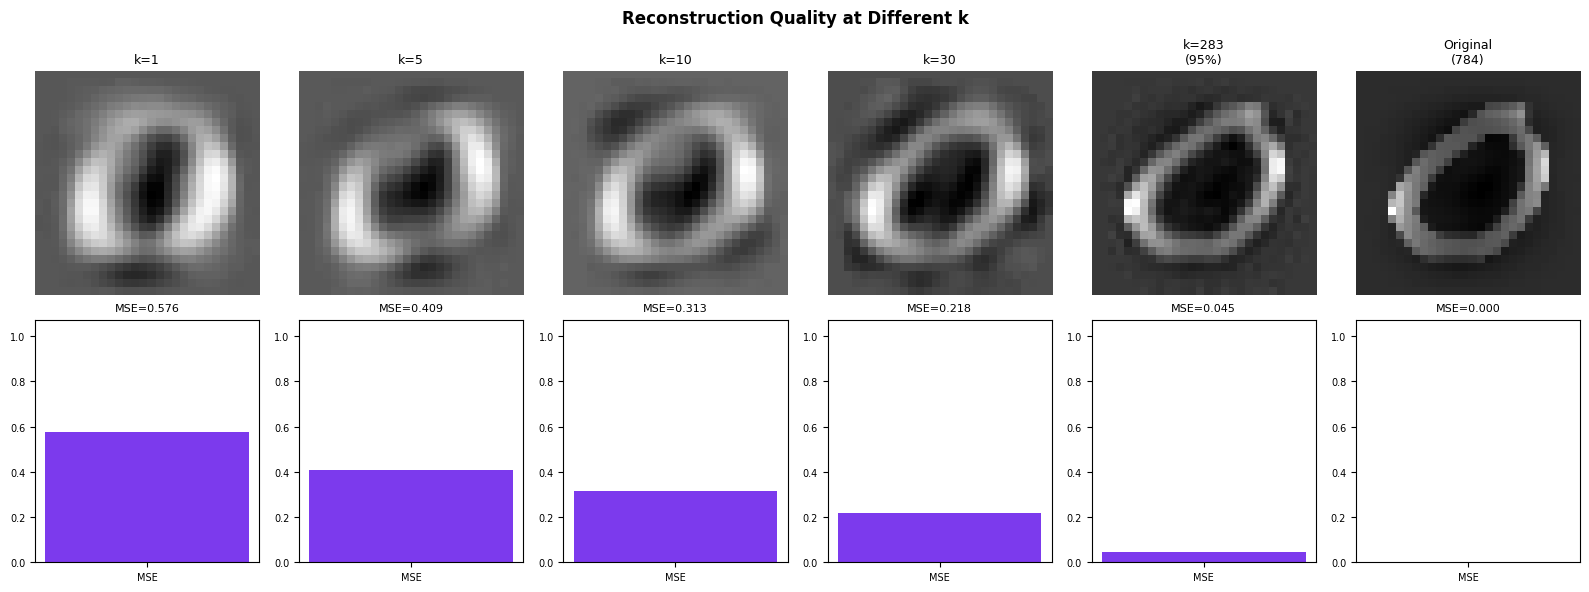

  ✓ Reconstruction plot saved.

✓ All visualizations saved.
✓ Analysis complete. Ready to present.


In [10]:
 # — Reconstruction quality at different k —
fig_r, axes_r = plt.subplots(2, 6, figsize=(16, 6))
original = X_train_scaled[0]
ks     = [1, 5, 10, 30, N_COMPONENTS, 784]
labels = ['k=1', 'k=5', 'k=10', 'k=30', f'k={N_COMPONENTS}\n(95%)', 'Original\n(784)']
 
for col, (k, label) in enumerate(zip(ks, labels)):
    if k == 784:
        img = original
    else:
        pca_k = PCA(n_components=k, random_state=42).fit(X_train_scaled)
        img   = pca_k.inverse_transform(pca_k.transform(original.reshape(1,-1))).flatten()
    axes_r[0, col].imshow(img.reshape(28, 28), cmap='gray')
    axes_r[0, col].set_title(label, fontsize=9)
    axes_r[0, col].axis('off')
    err = np.mean((original - img)**2)
    axes_r[1, col].bar(['MSE'], [err], color='#7C3AED')
    axes_r[1, col].set_ylim(0, original.var() * 1.1)
    axes_r[1, col].set_title(f'MSE={err:.3f}', fontsize=8)
    axes_r[1, col].tick_params(labelsize=7)
 
fig_r.suptitle('Reconstruction Quality at Different k', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("  ✓ Reconstruction plot saved.")
 
print("\n✓ All visualizations saved.")
print("✓ Analysis complete. Ready to present.")
 